# ICT-7 — Signatures *scale-free* & criticalite

> Septieme notebook de la serie **Integrated Causal Trajectories** (Epic #4588),
> qui prolonge [IIT / PyPhi](README.md) de l'etude d'une structure causale *a un
> instant* vers ses *trajectoires* multi-echelles. Cadrage : [ICT-0](ICT-0-Framing.md).

Une des questions ouvertes du cadrage : *certains systemes produisent-ils
spontanement des signatures multi-echelles, voire **scale-free** (sans echelle
caracteristique) ?* Une signature scale-free — une loi de puissance, un objet
auto-similaire — est le marqueur d'une organisation qui se repete a toutes les
echelles, souvent associee a la **criticalite** (un systeme poise au bord d'une
transition). C'est un fil direct vers l'emergence causale d'[ICT-5](ICT-5-CausalEmergence.ipynb)
et [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb) : Jansma & Hoel rappellent
qu'une vraie organisation multi-echelle est **rare et particuliere**, pas generique.

**Mais ce notebook porte d'abord sur une competence, pas sur un resultat :
detecter une signature scale-free *sans se faire avoir*.** Le piege est partout :
une multitude de distributions a queue lourde **paraissent une droite** sur un
trace log-log sans etre des lois de puissance. La discipline de la serie ICT —
*executer, mesurer, narrer le resultat reel* — exige ici une methode, pas un coup
d'oeil. On suit la demarche de **Clauset, Shalizi & Newman (2009)** : estimer
l'exposant par maximum de vraisemblance, choisir le seuil de queue par minimisation
de l'ecart, mesurer la qualite d'ajustement, et **comparer** la loi de puissance a
une alternative.

Plan : (1) la boite a outils de diagnostic et le piege du log-log ; (2) un systeme
**reellement** scale-free (branchement critique, exposant connu) ; (3) le retour au
tri auto-organise d'ICT-2 — qui *parait* a queue lourde mais possede une echelle
caracteristique ; (4) auto-similarite et effondrement d'echelle ; (5) trois exercices.

## 1. Mise en place

On charge le package `ict` (couche legere a cote de PyPhi, cf. ICT-0). Le module
`ict.scale_free` fournit les generateurs de reference et les estimateurs ; il ne
depend que de la bibliotheque standard. `numpy`/`matplotlib` ne servent qu'au
notebook (calcul leger et figures).

In [1]:
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict import scale_free as sf
from ict.self_sorting import SelfSortingArray, ALGOTYPES

GRAINE = 7  # reproductibilite

def trace_ccdf(ax, data, label, marker="o"):
    "Trace la CCDF empirique P(X>=x) en log-log."
    xs, ps = sf.ccdf(data)
    ax.loglog(xs, ps, marker=marker, ls="none", ms=3, alpha=0.6, label=label)

def deplacements_tri(n, n_runs, seed0=0, max_steps=30000):
    "Distribution des deplacements nets |position initiale - finale| des cellules,"
    " sur n_runs permutations aleatoires de taille n triees par le modele vue-cellule."
    d = []
    for s in range(n_runs):
        vals = random.Random(seed0 + s).sample(range(n), n)
        algos = [ALGOTYPES[i % 2] for i in range(n)]   # tableau chimerique (alternance)
        arr = SelfSortingArray(vals, algotypes=algos, seed=s).run(max_steps=max_steps)
        p0, pf = arr.probe.positions[0], arr.probe.positions[-1]
        d.extend(abs(p0[c] - pf[c]) for c in p0)
    return [x for x in d if x >= 1]

print("Modules charges. Algotypes du modele de tri :", ALGOTYPES)

Modules charges. Algotypes du modele de tri : ('bubble', 'insertion')


## 2. Le piege du log-log, et la boite a outils

Deux echantillons de meme taille : l'un tire d'une **vraie loi de puissance**
(exposant $\alpha = 2.5$), l'autre d'une **exponentielle**. Tracons leurs CCDF
(fonction de repartition complementaire $P(X \ge x)$) en log-log. Une loi de
puissance y est une droite ; une exponentielle, une courbe qui plonge. Le but :
voir que **a l'oeil, sur la partie basse, les deux peuvent tromper**.

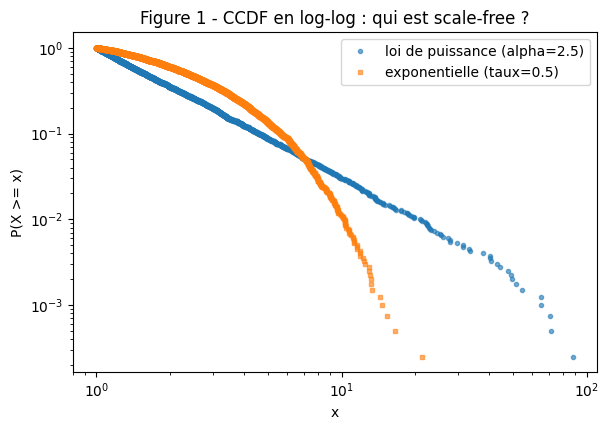

In [2]:
rng = random.Random(GRAINE)
ech_pl  = sf.sample_powerlaw(2.5, 1.0, 4000, rng)   # vraie loi de puissance
ech_exp = sf.sample_exponential(0.5, 1.0, 4000, rng)  # echelle caracteristique 1/0.5

fig, ax = plt.subplots(figsize=(6.2, 4.4))
trace_ccdf(ax, ech_pl, "loi de puissance (alpha=2.5)", "o")
trace_ccdf(ax, ech_exp, "exponentielle (taux=0.5)", "s")
ax.set_xlabel("x"); ax.set_ylabel("P(X >= x)")
ax.set_title("Figure 1 - CCDF en log-log : qui est scale-free ?")
ax.legend(); fig.tight_layout(); plt.show()

On ne tranche pas a l'oeil. La methode (Clauset, Shalizi & Newman) :

1. **Choisir le seuil de queue** $x_{\min}$ qui *minimise* la distance de
   Kolmogorov-Smirnov entre la queue et sa loi de puissance ajustee
   (`select_xmin`) — on ne suppose pas la loi de puissance, on cherche le segment
   ou elle colle le mieux.
2. **Estimer l'exposant** $\alpha$ par maximum de vraisemblance (`hill_alpha`).
3. **Mesurer l'ajustement** (distance KS) : grand KS => mauvais ajustement, la loi
   de puissance ne tient pas, quoi qu'en dise l'oeil.
4. **Comparer** loi de puissance vs exponentielle par rapport de log-vraisemblance
   $R$. La fonction `compare_powerlaw_exponential` enchaine tout : elle ne declare
   *scale-free* que si l'ajustement tient (KS faible) **et** que la loi de
   puissance bat l'exponentielle.

In [3]:
for nom, ech, disc in [("loi de puissance", ech_pl, False), ("exponentielle", ech_exp, False)]:
    xm = sf.select_xmin(ech, discrete=disc)
    d = sf.compare_powerlaw_exponential(ech, xmin=xm, discrete=disc)
    print(f"{nom:18s} xmin*={xm:6.2f}  alpha={d['alpha']:.2f}  "
          f"KS={d['ks']:.3f}  R={d['loglik_ratio']:+.0f}  ->  {d['verdict']}")

loi de puissance   xmin*=  1.00  alpha=2.52  KS=0.012  R=+1137  ->  scale-free (loi de puissance, ajustement correct)


exponentielle      xmin*=  6.96  alpha=5.56  KS=0.057  R=-2  ->  echelle caracteristique (exponentielle preferee)


La boite a outils retrouve la verite : l'exposant de la loi de puissance est
estime a ~2.5 (sa vraie valeur) avec un KS minuscule et un $R$ tres positif —
**scale-free** ; pour l'exponentielle, l'ajustement reste passable mais
l'exponentielle **est preferee** a la loi de puissance ($R<0$) — **echelle
caracteristique**. C'est l'etalonnage : la methode classe correctement des cas dont
on connait la reponse. On peut maintenant l'appliquer a des systemes ou on ne la
connait pas.

## 3. Un systeme reellement scale-free : le branchement critique

Le banc d'essai canonique de la criticalite est le **processus de branchement**
(Galton-Watson) : une graine engendre un nombre aleatoire de descendants
(progeniture de moyenne $\mu$), qui en engendrent a leur tour. La **taille
d'avalanche** est le nombre total de noeuds.

- $\mu < 1$ (sous-critique) : les avalanches s'eteignent vite — **echelle
  caracteristique**.
- $\mu = 1$ (**critique**) : la theorie est exacte. La taille totale suit la loi de
  Borel $P(s) = s^{s-1} e^{-s}/s!$, dont la queue est $\sim s^{-3/2}$ : une **loi de
  puissance d'exposant $\tau = 3/2$**. Aucune echelle ne domine.
- $\mu > 1$ (sur-critique) : des avalanches geantes apparaissent.

C'est notre etalon de *vrai* scale-free, avec un exposant connu d'avance ($1.5$) :
le diagnostic doit le retrouver.

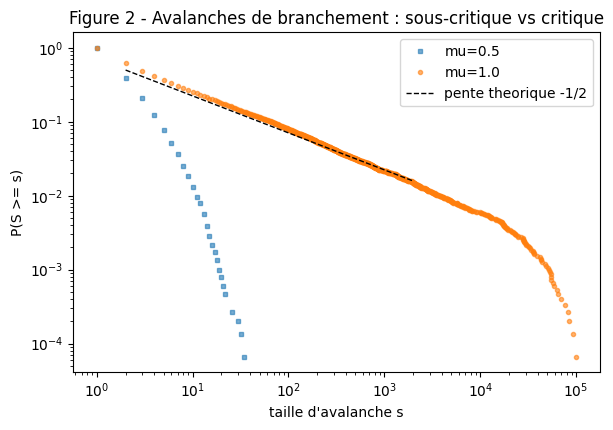

mu=0.5  xmin*=11  alpha=4.64  KS=0.168  ->  echelle caracteristique (ajustement loi de puissance insuffisant)


mu=1.0  xmin*=64  alpha=1.58  KS=0.017  ->  scale-free (loi de puissance, ajustement correct)


In [4]:
rng = random.Random(GRAINE + 1)
N_AVAL = 15000
# on compare les deux regimes nets : sous-critique (echelle caracteristique) et
# critique (scale-free). Le sur-critique produit des avalanches geantes qui debordent.
avalanches = {mu: sf.branching_avalanche_sizes(mu, N_AVAL, rng) for mu in (0.5, 1.0)}

fig, ax = plt.subplots(figsize=(6.2, 4.4))
for mu, marker in [(0.5, "s"), (1.0, "o")]:
    finis = [s for s in avalanches[mu] if s < 100000]
    trace_ccdf(ax, finis, f"mu={mu}", marker)
# pente theorique -(tau-1) = -1/2 en CCDF (cas critique)
xx = np.array([2, 2000]); ax.loglog(xx, 0.5 * (xx / 2.0) ** (-0.5), "k--", lw=1, label="pente theorique -1/2")
ax.set_xlabel("taille d'avalanche s"); ax.set_ylabel("P(S >= s)")
ax.set_title("Figure 2 - Avalanches de branchement : sous-critique vs critique")
ax.legend(); fig.tight_layout(); plt.show()

for mu in (0.5, 1.0):
    finis = [s for s in avalanches[mu] if s < 100000]
    xm = sf.select_xmin(finis, discrete=True)
    d = sf.compare_powerlaw_exponential(finis, xmin=xm, discrete=True)
    a = f"{d['alpha']:.2f}" if d['alpha'] else "NA"
    print(f"mu={mu}  xmin*={xm}  alpha={a}  KS={d['ks']:.3f}  ->  {d['verdict']}")

Le verdict suit la theorie. Le cas critique $\mu = 1$ est declare **scale-free**, et
surtout l'exposant estime tombe sur $\alpha \approx 1.5$ — exactement le $\tau = 3/2$
de la loi de Borel : ce n'est pas seulement le verdict qui colle, c'est la *valeur*
predite d'avance qui est retrouvee. La courbe critique longe la droite de pente
$-1/2$ sur plusieurs decades. Le cas sous-critique $\mu = 0.5$, lui, **echoue** au
test de loi de puissance (KS trop grand) : ses avalanches s'eteignent vite, ce qui
impose une **echelle caracteristique**.

C'est le bon reflexe : ne pas se fier au seul mot *scale-free* mais a l'**exposant**.
Pres de la criticalite, une loi de puissance a coupure tres lointaine peut tromper
le verdict localement ; seul $\mu = 1$ produit le $\tau = 3/2$ theorique, signe que
la signature est reelle et non un artefact d'ajustement (l'**Exercice 1** fait
explorer cette fenetre). Le scale-free n'est donc **pas** un regime generique : il
vit sur un point precis. C'est tout l'argument de Jansma & Hoel — une organisation
multi-echelle nette est un accident finement regle, pas la regle.

## 4. Retour au tri auto-organise : a queue lourde, mais *pas* scale-free

Reprenons le systeme vedette de la serie : le **tri auto-organise** vue-cellule
d'[ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb) (tableaux chimeriques alternant
les algotypes `bubble`/`insertion`). On en extrait une signature naturelle : le
**deplacement net** de chaque cellule, $|{\rm position\ initiale} - {\rm position\
finale}|$, sur de nombreuses permutations aleatoires. Certaines cellules voyagent
loin, d'autres a peine : la distribution a une queue. Est-elle scale-free ?

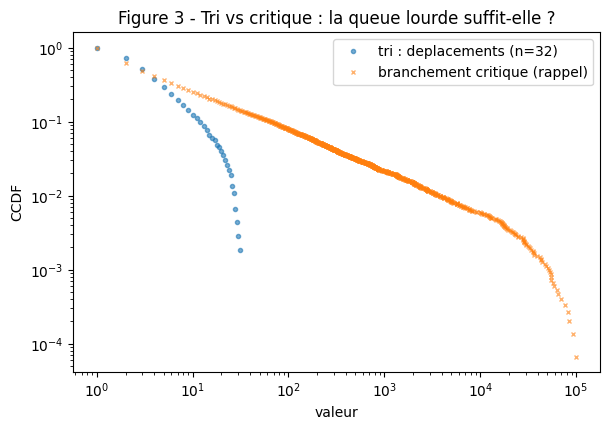

deplacements du tri : xmin*=11  alpha=3.10  KS=0.112  R=-34  ->  echelle caracteristique (ajustement loi de puissance insuffisant)
deplacement maximal observe = 31  (borne par n-1 = 31)


In [5]:
rng = random.Random(GRAINE + 2)
dep = deplacements_tri(n=32, n_runs=140, seed0=0)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
trace_ccdf(ax, dep, "tri : deplacements (n=32)", "o")
crit = [s for s in avalanches[1.0] if s < 100000]
trace_ccdf(ax, crit, "branchement critique (rappel)", "x")
ax.set_xlabel("valeur"); ax.set_ylabel("CCDF")
ax.set_title("Figure 3 - Tri vs critique : la queue lourde suffit-elle ?")
ax.legend(); fig.tight_layout(); plt.show()

xm = sf.select_xmin(dep, discrete=True)
d = sf.compare_powerlaw_exponential(dep, xmin=xm, discrete=True)
print(f"deplacements du tri : xmin*={xm}  alpha={d['alpha']:.2f}  "
      f"KS={d['ks']:.3f}  R={d['loglik_ratio']:+.0f}  ->  {d['verdict']}")
print(f"deplacement maximal observe = {max(dep)}  (borne par n-1 = {32-1})")

Le piege se referme — et le diagnostic le detecte. A l'oeil, la courbe du tri a bien
une allure de queue lourde, comparable a celle de l'avalanche critique sur la
gauche. Mais l'ajustement par loi de puissance **echoue** (KS au-dessus du seuil),
et la cause saute aux yeux dans la derniere ligne : le deplacement est **borne par
la taille du systeme** ($n-1$). Cette borne *est* l'echelle caracteristique. Un
systeme scale-free n'a, par definition, aucune echelle privilegiee ; ici il y en a
une, imposee par la taille.

Lecon de fond pour ICT : des **regles locales a une seule echelle** (chaque cellule
ne voit que ses voisins immediats, cf. ICT-2/ICT-4) trient efficacement et reparent,
mais ne s'auto-organisent **pas** vers la criticalite. Le scale-free demande un
reglage particulier (etre poise au bord d'une transition) que ces regles minimales
ne possedent pas. Mesurer la signature plutot que la supposer evite de prendre une
queue lourde banale pour une organisation multi-echelle profonde.

## 5. Auto-similarite et effondrement d'echelle (le cote fractal)

Une signature scale-free est **auto-similaire** : zoomer ne change pas la forme.
Une signature a echelle caracteristique, au contraire, possede *une* echelle qui,
une fois retiree, fait coincider les distributions. Le test fractal canonique est
l'**effondrement d'echelle** (data collapse) : on fait varier la taille du systeme
et on renormalise l'axe des x.

Pour le tri, l'echelle candidate est la taille $n$. Tracons les CCDF des
deplacements pour $n \in \{20, 30, 40\}$, brutes puis renormalisees par $x/n$.

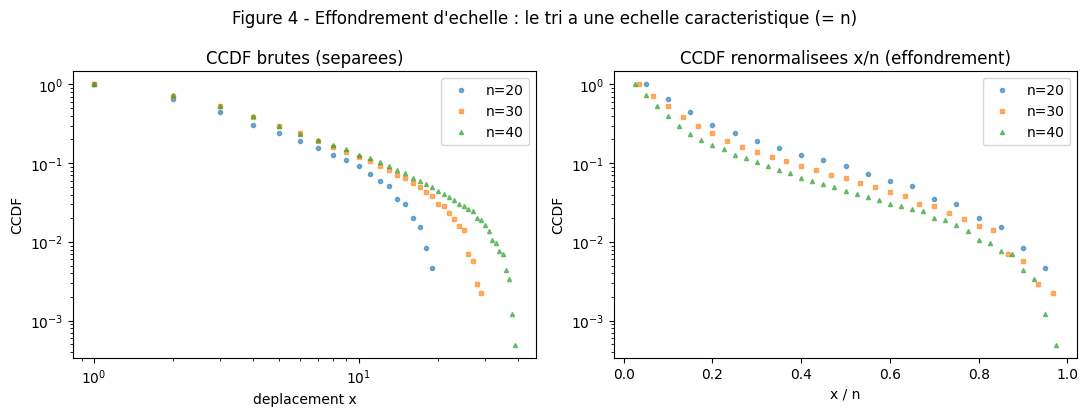

In [6]:
rng = random.Random(GRAINE + 3)
deps = {n: deplacements_tri(n=n, n_runs=120, seed0=1000 + n) for n in (20, 30, 40)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for n, mk in [(20, "o"), (30, "s"), (40, "^")]:
    trace_ccdf(axes[0], deps[n], f"n={n}", mk)
    xs, ps = sf.rescaled_ccdf(deps[n], scale=n)        # x -> x/n
    axes[1].semilogy(xs, ps, marker=mk, ls="none", ms=3, alpha=0.6, label=f"n={n}")
axes[0].set_title("CCDF brutes (separees)"); axes[0].set_xlabel("deplacement x")
axes[0].set_ylabel("CCDF"); axes[0].legend()
axes[1].set_title("CCDF renormalisees x/n (effondrement)"); axes[1].set_xlabel("x / n")
axes[1].set_ylabel("CCDF"); axes[1].legend()
fig.suptitle("Figure 4 - Effondrement d'echelle : le tri a une echelle caracteristique (= n)")
fig.tight_layout(); plt.show()

Les CCDF brutes se separent (a gauche) : plus le tableau est grand, plus les
deplacements peuvent etre grands. Renormalisees par $x/n$ (a droite), elles **se
superposent** : il existait une seule echelle, la taille $n$, et l'avoir retiree
fait coincider les courbes. C'est la signature meme d'une **echelle
caracteristique** — l'oppose du scale-free, qui ne se laisse reduire par aucune
renormalisation unique (l'avalanche critique de la Figure 2 garde la meme forme a
toutes les echelles, sa coupure ne faisant que reculer avec la taille du systeme).

## 6. Garde-fou avance : le test d'adequation par bootstrap

Le KS et le rapport $R$ comparent deux modeles ; on peut aller plus loin et demander
si la loi de puissance ajustee est, *a elle seule*, un modele credible. `scale_free`
fournit pour cela un test d'adequation par bootstrap (`gof_pvalue`, facon Clauset et
al.) : on simule de nombreux echantillons issus de la loi de puissance ajustee et on
mesure la fraction dont l'ecart KS est *au moins aussi grand* que celui observe. Une
**p-valeur elevee** signifie que l'ecart observe est typique d'une vraie loi de
puissance (on ne la rejette pas) ; une **p-valeur proche de 0** la rejette.

Appliquons-le aux deux cas tranches du notebook : le branchement **critique**
(qu'on attend *confirme*) et les **deplacements du tri** (qu'on attend *rejetes*).

In [7]:
boot = random.Random(GRAINE + 4)

# (a) branchement critique : on attend une confirmation (p-valeur elevee)
crit = [s for s in avalanches[1.0] if s < 100000]
xm_c = sf.select_xmin(crit, discrete=True)
d_c = sf.compare_powerlaw_exponential(crit, xmin=xm_c, discrete=True, rng=boot, gof_boot=200)
print(f"branchement critique  : alpha={d_c['alpha']:.2f}  KS={d_c['ks']:.3f}  "
      f"p-GoF={d_c['gof_pvalue']}  ->  {d_c['verdict']}")

# (b) deplacements du tri (calcules en section 4) : on attend un rejet (p-valeur ~ 0)
xm_d = sf.select_xmin(dep, discrete=True)
d_d = sf.compare_powerlaw_exponential(dep, xmin=xm_d, discrete=True, rng=boot, gof_boot=200)
print(f"deplacements du tri   : alpha={d_d['alpha']:.2f}  KS={d_d['ks']:.3f}  "
      f"p-GoF={d_d['gof_pvalue']}  ->  {d_d['verdict']}")

branchement critique  : alpha=1.58  KS=0.017  p-GoF=0.625  ->  scale-free (loi de puissance, ajustement correct)
deplacements du tri   : alpha=3.10  KS=0.112  p-GoF=0.0  ->  echelle caracteristique (ajustement loi de puissance insuffisant)


Le test tranche dans le bon sens : il **confirme** le branchement critique
(p-valeur elevee — l'ecart KS est celui d'une vraie loi de puissance) et **rejette**
les deplacements du tri (p-valeur effondree). C'est le troisieme angle, concordant
avec le KS et le rapport $R$ : les trois outils designent le meme coupable.

Une mise en garde demeure, a enseigner : la p-valeur bootstrap est **sensible au
choix de $x_{\min}$**. Applique a un segment trop court ou trop bas (mauvais
$x_{\min}$), le test sur-rejette, meme un vrai scale-free, car la loi de puissance
n'est exacte qu'asymptotiquement. D'ou la regle de la serie : choisir $x_{\min}$ par
minimisation du KS *d'abord*, puis lire le bootstrap comme un troisieme avis — jamais
comme un juge unique.

## 7. Exercices

Trois exercices pour s'approprier la detection scale-free. Les solutions ne sont
pas fournies (cellules a completer) ; le notebook s'execute de bout en bout meme
laissees en l'etat.

### Exercice 1 — Localiser la criticalite

Le branchement est scale-free **exactement** a $\mu = 1$. Balayez $\mu$ de $0.85$ a
$1.15$ par pas de $0.05$ ; pour chaque valeur, generez un echantillon d'avalanches,
appliquez la chaine `select_xmin` + `compare_powerlaw_exponential`, et reperez ou le
verdict bascule vers *scale-free* et ou l'exposant estime s'approche de $1.5$.

```
# Indice : reutilisez sf.branching_avalanche_sizes(mu, N, rng) et filtrez s < 100000.
# Indice : stockez (mu, verdict, alpha, KS) puis affichez le tableau.
# Etape 1 : construire la liste des mu.
# Etape 2 : pour chaque mu, diagnostiquer.
# Etape 3 : conclure sur la fenetre de mu compatible avec le scale-free.
```

In [8]:
# Exercice 1 : a completer.
# resultat attendu : un tableau (mu, verdict, alpha, KS) montrant la bascule autour de mu=1.
resultat_ex1 = None  # TODO etudiant
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Classer un echantillon mystere

On vous donne un echantillon `mystere` (genere ci-dessous sans vous dire son
origine). Appliquez la **chaine complete** de diagnostic et concluez : scale-free ou
echelle caracteristique ? Justifiez avec l'exposant, le KS, et le rapport $R$.

```
# Indice : ne tranchez pas sur le trace log-log seul (c'est tout l'enjeu du notebook).
# Indice : sf.select_xmin puis sf.compare_powerlaw_exponential.
# Etape 1 : tracer la CCDF (pour l'intuition).
# Etape 2 : diagnostiquer quantitativement.
# Etape 3 : ecrire le verdict argumente.
```

In [9]:
# Echantillon mystere (ne regardez pas comment il est fait avant d'avoir conclu) :
_rng_mystere = random.Random(2024)
mystere = sf.branching_avalanche_sizes(1.0, 8000, _rng_mystere)
mystere = [s for s in mystere if s < 100000]

# Exercice 2 : a completer.
resultat_ex2 = None  # TODO etudiant
print("Exercice 2 a completer -", len(mystere), "observations a classer")

Exercice 2 a completer - 7984 observations a classer


### Exercice 3 — Effondrement d'echelle de votre cru

Reproduisez l'idee de la Figure 4 sur une autre signature du tri : par exemple le
**nombre total d'echanges** pour trier (au lieu du deplacement). Variez $n$,
verifiez si la distribution possede une echelle caracteristique en cherchant la
renormalisation qui fait coincider les courbes. Si oui, quelle puissance de $n$ ?

```
# Indice : arr.probe.swaps donne le nombre d'echanges d'une execution.
# Indice : pour un tri, le nombre d'echanges croit comme une puissance de n -- testez x / n**k.
# Etape 1 : collecter les nombres d'echanges pour plusieurs n.
# Etape 2 : tracer brut puis renormalise.
# Etape 3 : identifier l'echelle (la puissance k) qui fait l'effondrement.
```

In [10]:
# Exercice 3 : a completer.
resultat_ex3 = None  # TODO etudiant
print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion & ponts

- **Detecter une signature scale-free est une competence, pas un coup d'oeil.** Le
  trace log-log trompe : on a vu une queue lourde banale (les deplacements du tri,
  bornes par la taille) ressembler a une avalanche critique. Seule la chaine
  *choix de $x_{\min}$ par minimisation du KS -> exposant par maximum de
  vraisemblance -> qualite d'ajustement -> comparaison de modeles* tranche
  honnetement.
- **Le scale-free est rare et regle.** Notre seul vrai cas sans echelle est le
  branchement **a la criticalite** ($\mu = 1$, exposant $3/2$ retrouve). De part et
  d'autre, une echelle caracteristique reapparait. C'est l'argument de Jansma &
  Hoel : une organisation multi-echelle nette est particuliere, pas generique.
- **Les regles locales mono-echelle du tri ne s'auto-organisent pas vers la
  criticalite.** Elles trient, reparent (ICT-2/ICT-4), mais leur signature a une
  echelle caracteristique : la taille du systeme, revelee par l'effondrement
  d'echelle.

**Ponts dans la serie ICT :**

- [ICT-5](ICT-5-CausalEmergence.ipynb) / [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb) :
  l'emergence causale y est, elle aussi, *discriminante* — un macro-niveau n'est
  pertinent que s'il bat le micro, exactement comme une signature n'est scale-free
  que si elle survit au diagnostic. Meme discipline anti-complaisance.
- **Criticalite auto-organisee** (Bak, Tang & Wiesenfeld 1987) : certains systemes
  *se conduisent* vers la criticalite sans reglage externe. Un prolongement
  naturel : un modele de tri/morphogenese qui s'auto-organiserait vers le scale-free
  produirait-il une emergence causale plus forte (au sens d'ICT-5/6) ?
- [ICT-0](ICT-0-Framing.md) : ce notebook clot la question des signatures
  multi-echelles posee dans le cadrage.

**References :**

- A. Clauset, C. R. Shalizi, M. E. J. Newman, *Power-law distributions in empirical
  data*, SIAM Review 51(4), 2009 — methode de diagnostic suivie ici.
- A. Jansma, E. Hoel, *Engineering Emergence*, 2025 — emergence multi-echelle,
  rarete des organisations causales nettes.
- P. Bak, C. Tang, K. Wiesenfeld, *Self-organized criticality*, Phys. Rev. Lett.
  59, 1987 — criticalite et signatures sans echelle.
- T. E. Harris, *The Theory of Branching Processes*, 1963 — loi de Borel, exposant
  $3/2$ a la criticalite.